## Nova Financial Analysis

This project uses Python for financial data analysis and insight generation. It relies on:

* **pandas** for data manipulation and analysis
* **matplotlib** for visualizing trends in financial datasets

The notebooks and scripts explore stock market data, compute technical indicators, and present visualizations that support better financial decision-making.

---

## Financial News Analysis

This notebook focuses on analyzing a dataset of financial news headlines. It includes the following steps:

* Loading the raw analyst ratings dataset and parsing date fields
* Computing headline lengths to study text characteristics and distribution
* Counting and ranking publishers to identify the most active news sources

This analysis helps uncover patterns in the dataset and prepares the data for further work such as sentiment analysis and statistical modeling.


In [2]:
import pandas as pd
import numpy as np

print("Environment working!")

Environment working!


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
import pandas as pd

# Load data directly
df = pd.read_csv("../data/raw/raw_analyst_ratings.csv", parse_dates=['date'])

# Headline length
df['headline_length'] = df['headline'].apply(len)
print(df['headline_length'].describe())

# Articles per publisher
publisher_counts = df['publisher'].value_counts()
print(publisher_counts.head(10))

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64



## Daily Article Analysis
This code analyzes the frequency of financial news articles over time:

- Converts the date column to proper datetime format.
- Groups articles by day to count how many were published each day.
- Displays the first 10 days to get an overview of publishing patterns.
This helps identify trends and periods of high or low news activity.

In [10]:
# Convert 'date' to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Articles per day
articles_per_day = df.groupby(df['date'].dt.date).size()
articles_per_day.head(10)

date
2011-04-27    1
2011-04-28    2
2011-04-29    2
2011-04-30    1
2011-05-01    1
2011-05-02    9
2011-05-03    3
2011-05-05    3
2011-05-06    3
2011-05-07    2
dtype: int64

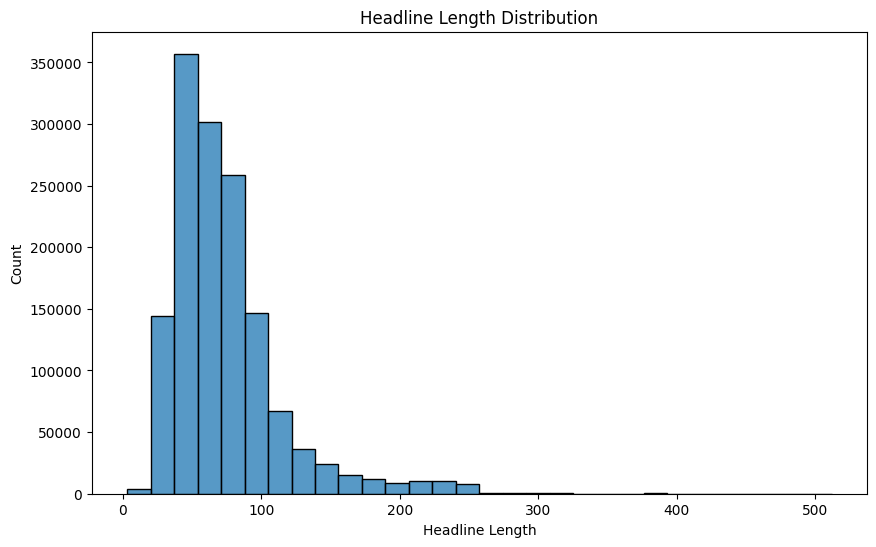

In [11]:
plt.figure(figsize=(10,6))
sns.histplot(df['headline_length'], bins=30)
plt.title("Headline Length Distribution")
plt.xlabel("Headline Length")
plt.show()

In [12]:
publisher_counts = df['publisher'].value_counts().head(10)

publisher_counts

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

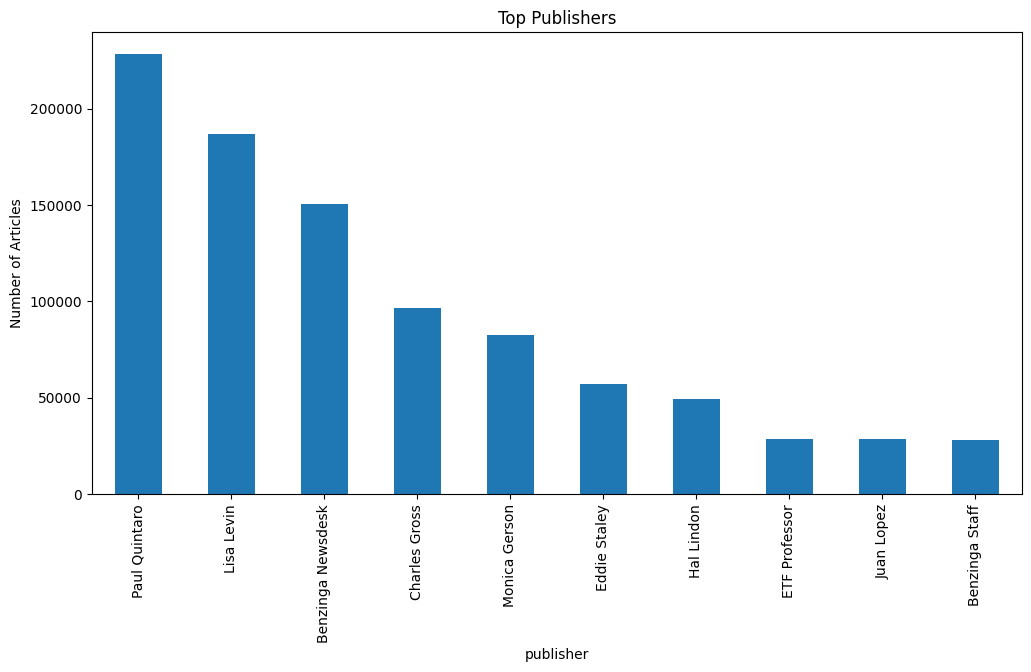

In [13]:
plt.figure(figsize=(12,6))
publisher_counts.plot(kind='bar')
plt.title("Top Publishers")
plt.ylabel("Number of Articles")
plt.show()

In [14]:
df['domain'] = df['publisher'].str.extract(r'@([\w\.-]+)')

In [15]:
df['domain'].value_counts().head(10)

domain
benzinga.com              7937
gmail.com                  139
andyswan.com                 5
investdiva.com               2
tothetick.com                2
eosdetroit.io                1
forextraininggroup.com       1
stockmetrix.net              1
Name: count, dtype: int64

- Convert date column and extract date

In [16]:
df['date'] = pd.to_datetime(df['date'])

In [17]:
df['day'] = df['date'].dt.date

## Analyze Publishing Hours

In [18]:
df['hour'] = df['date'].dt.hour

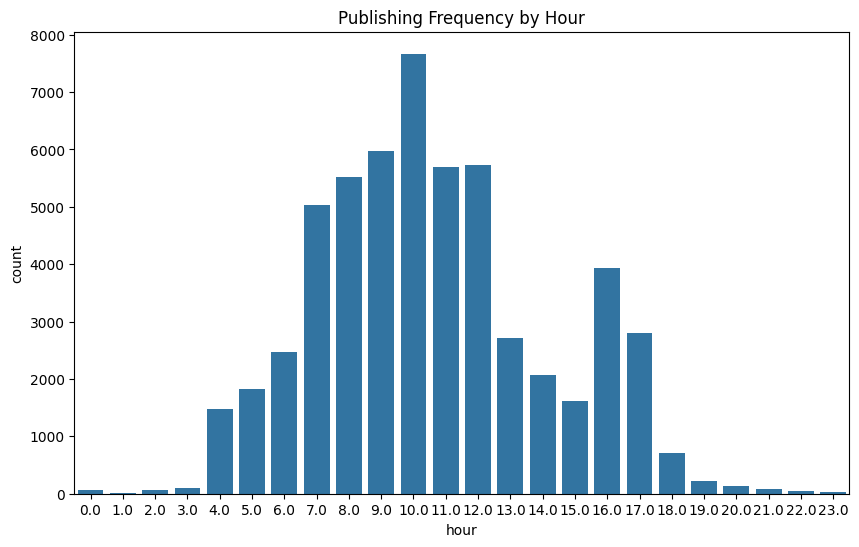

In [19]:
plt.figure(figsize=(10,6))
sns.countplot(x='hour', data=df)
plt.title("Publishing Frequency by Hour")
plt.show()

## Text Cleaning

In [20]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['clean_headline'] = df['headline'].apply(clean_text)

## TF-IDF Keyword Extraction

In [21]:
tfidf = TfidfVectorizer(max_features=20)

X = tfidf.fit_transform(df['clean_headline'])

keywords = tfidf.get_feature_names_out()

keywords

array(['announces', 'benzinga', 'buy', 'downgrades', 'earnings', 'eps',
       'est', 'market', 'mid', 'price', 'pt', 'reports', 'sales',
       'shares', 'stocks', 'top', 'trading', 'update', 'vs', 'week'],
      dtype=object)

## Word Cloud Visualization

In [24]:
# Clean data first
df['headline'] = df['headline'].dropna().astype(str)

# Create sample text
sample_text = " ".join(df['headline'].sample(n=5000, random_state=42))

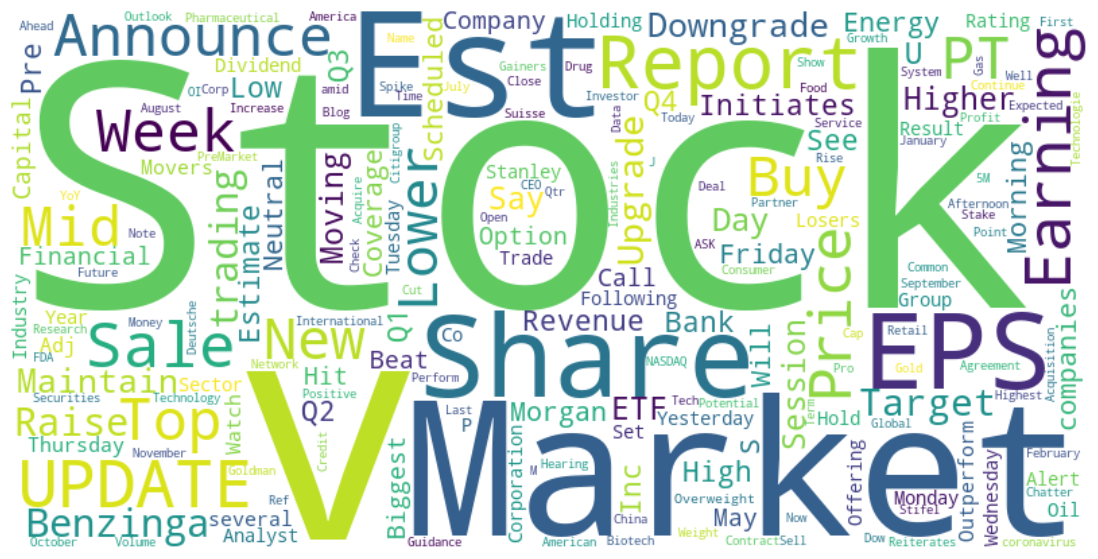

In [25]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=200,
    collocations=False
).generate(sample_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

In [26]:
keywords = ['earnings', 'fda', 'price target', 'upgrade']

for word in keywords:
    count = df['clean_headline'].str.contains(word).sum()
    print(word, count)

earnings 86626
fda 11382
price target 47634
upgrade 62091


# Step 26 — Insights from Descriptive Statistics

## 1. Headline Length Distribution Insight

The dataset contains **1,407,328 financial news headlines**, showing a very large and active news stream.

Headline length statistics show:

* **Mean length:** ~73 characters
* **Median (50%):** 64 characters
* **Minimum:** 3 characters
* **Maximum:** 512 characters
* **Standard deviation:** ~40 characters

### 📌 Interpretation:

Most financial news headlines are **short and concise**, typically between **47 and 87 characters (IQR range)**. This suggests that financial news is designed for **quick consumption and rapid decision-making**, which aligns with high-frequency trading environments.

The presence of extremely long headlines (up to 512 characters) indicates occasional **detailed announcements or multi-event summaries**, but these are rare outliers.

### Key Insight:

> Financial news headlines are highly compressed, reinforcing their role as fast-moving market signals rather than detailed articles.

---

## 2. Publisher Activity Insight

The dataset is dominated by a small number of highly active publishers:

Top contributors:

* Paul Quintaro → 228,373 articles
* Lisa Levin → 186,979 articles
* Benzinga Newsdesk → 150,484 articles
* Charles Gross → 96,732 articles
* Monica Gerson → 82,380 articles

### 📌 Interpretation:

A **small group of publishers contributes a disproportionately large share of all news**, indicating a highly centralized information production system.

Notably, several top publishers (e.g., Benzinga Newsdesk, Benzinga Staff) suggest that **automated or institutional news feeds** play a major role in generating financial headlines.

### Key Insight:

> Financial news distribution is heavily concentrated among a few publishers, which may amplify their influence on market sentiment and stock reactions.

---

## 3. Market Structure Insight (Combined View)

When combining headline length and publisher behavior:

* News is **short, frequent, and standardized**
* A few publishers generate most of the content
* Information flow is likely **algorithmic and high-frequency in nature**

### 📌 Final Insight:

> The financial news ecosystem behaves like a high-throughput information network where a few dominant publishers generate large volumes of concise, market-moving headlines.

